# Analiza slovenskega trga nepremičnin (2015–2025)
## 10 največjih občin

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Nastavitve ──────────────────────────────────────────────────────────────
DATA_PATH = "vse.csv"

OBCINE = [
    "CELJE", "DOMŽALE", "KAMNIK", "KOPER", "KRANJ",
    "LJUBLJANA", "MARIBOR", "NOVA GORICA", "NOVO MESTO", "VELENJE"
]

# Bivanjske nepremičnine: koda 1 (enostanovanjska hiša) in 2 (stanovanje)
BIVANJSKE = [1, 2]

# Nebivanjske nepremičnine: vse ostale kode
NEBIVANJSKE = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

# Tržni posli
TRZNI = [1]

# ── Nalaganje in čiščenje podatkov ──────────────────────────────────────────
df = pd.read_csv(DATA_PATH, low_memory=False)

# Filtriramo na 10 občin
df = df[df["OBCINA"].isin(OBCINE)].copy()

# Filtriramo samo tržne posle
df = df[df["TRZNOST_POSLA"].isin(TRZNI)]

# Površina: PRODANA_POVRSINA > 0
df = df[df["PRODANA_POVRSINA"] > 0]

# Cena > 0
df = df[df["POGODBENA_CENA_ODSKODNINA"] > 0]

# Izračun cene na m²
df["CENA_M2"] = df["POGODBENA_CENA_ODSKODNINA"] / df["PRODANA_POVRSINA"]

# Kategorija nepremičnine
df["TIP"] = df["VRSTA_DELA_STAVBE"].apply(
    lambda x: "Bivanjska" if x in BIVANJSKE else "Nebivanjska"
)

print(f"Skupaj zapisov po filtriranju: {len(df):,}")
print(df.groupby(["OBCINA", "TIP"]).size().unstack(fill_value=0))

Skupaj zapisov po filtriranju: 42,695
TIP          Bivanjska  Nebivanjska
OBCINA                             
CELJE             1874          404
DOMŽALE           1086          588
KAMNIK             770          330
KOPER             1191          497
KRANJ             1720          578
LJUBLJANA        12785         9200
MARIBOR           6184         2027
NOVA GORICA        631          207
NOVO MESTO         891          249
VELENJE           1212          271


## Povprečna cena na m² po občinah (vse nepremičnine skupaj)

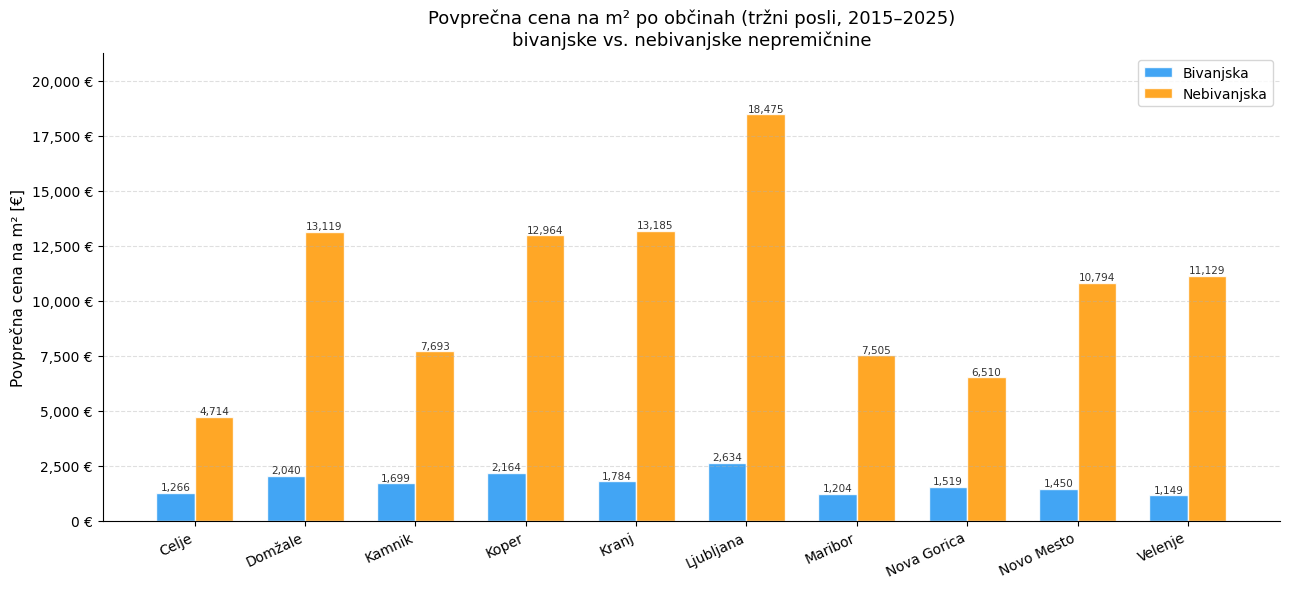


Povzetek:
     OBCINA         TIP    povprecje      mediana  stevilo
      CELJE   Bivanjska  1265.996085  1108.108108     1873
      CELJE Nebivanjska  4713.629869  1142.400000      375
    DOMŽALE   Bivanjska  2039.927430  1912.032037     1085
    DOMŽALE Nebivanjska 13118.748330 12857.142857      579
     KAMNIK   Bivanjska  1698.661141  1528.594771      766
     KAMNIK Nebivanjska  7692.819716  6538.461538      319
      KOPER   Bivanjska  2163.674521  1955.533597     1190
      KOPER Nebivanjska 12964.125337  7214.285714      487
      KRANJ   Bivanjska  1784.225370  1612.903226     1719
      KRANJ Nebivanjska 13184.920644  7003.205128      538
  LJUBLJANA   Bivanjska  2634.467804  2358.870968    12781
  LJUBLJANA Nebivanjska 18474.635648 13189.293750     8723
    MARIBOR   Bivanjska  1203.874175  1047.847985     6156
    MARIBOR Nebivanjska  7504.522849  2873.015873     1848
NOVA GORICA   Bivanjska  1519.068065  1451.976391      622
NOVA GORICA Nebivanjska  6510.075986  1614.94

: 

: 

: 

In [ ]:
# Izločimo ekstremne outlierje (pod 1. percentilom in nad 99. percentilom cene/m²)
q_low = df["CENA_M2"].quantile(0.01)
q_high = df["CENA_M2"].quantile(0.99)
df_clean = df[(df["CENA_M2"] >= q_low) & (df["CENA_M2"] <= q_high)]

# Povprečna in mediana cena na m² po občini in tipu nepremičnine
agg = (
    df_clean
    .groupby(["OBCINA", "TIP"])["CENA_M2"]
    .agg(povprecje="mean", mediana="median", stevilo="count")
    .reset_index()
)

# ── Graf: povprečna cena/m² po občinah – bivanjske vs nebivanjske ────────────
fig, ax = plt.subplots(figsize=(13, 6))

tips = ["Bivanjska", "Nebivanjska"]
colors = ["#2196F3", "#FF9800"]
x = np.arange(len(OBCINE))
width = 0.35

for i, (tip, color) in enumerate(zip(tips, colors)):
    subset = agg[agg["TIP"] == tip].set_index("OBCINA")
    vals = [subset.loc[o, "povprecje"] if o in subset.index else 0 for o in OBCINE]
    ns   = [int(subset.loc[o, "stevilo"]) if o in subset.index else 0 for o in OBCINE]
    bars = ax.bar(x + i * width - width / 2, vals, width, label=tip, color=color, alpha=0.85, edgecolor="white")

    for bar, val, n in zip(bars, vals, ns):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                f"{val:,.0f}",
                ha="center", va="bottom", fontsize=7.5, color="#333"
            )

ax.set_xticks(x)
ax.set_xticklabels([o.title() for o in OBCINE], rotation=25, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax.set_ylabel("Povprečna cena na m² [€]", fontsize=11)
ax.set_title("Povprečna cena na m² po občinah (tržni posli, 2015–2025)\nbivanjske vs. nebivanjske nepremičnine", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, agg["povprecje"].max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nPovzetek:")
print(agg[["OBCINA","TIP","povprecje","mediana","stevilo"]].to_string(index=False))

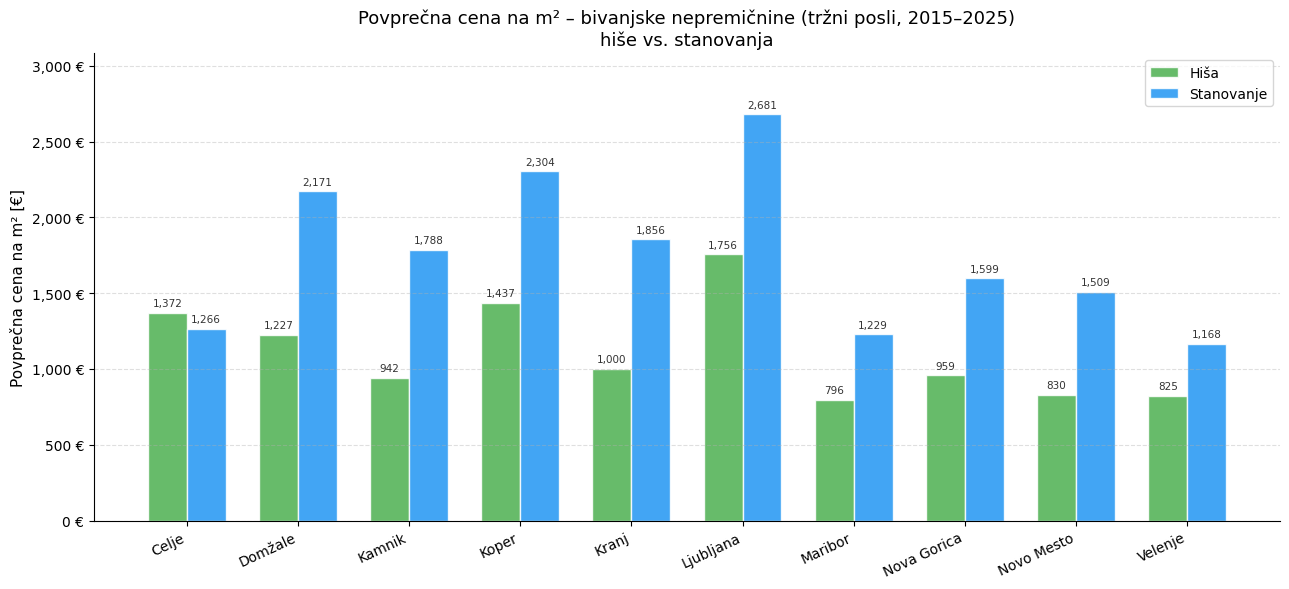


Povzetek – bivanjske nepremičnine:
     OBCINA     PODTIP   povprecje     mediana  stevilo
      CELJE       Hiša 1372.450555 1026.315789        3
      CELJE Stanovanje 1265.825303 1108.279406     1870
    DOMŽALE       Hiša 1226.565790 1111.111111      151
    DOMŽALE Stanovanje 2171.423798 2031.513648      934
     KAMNIK       Hiša  942.379983  806.034483       81
     KAMNIK Stanovanje 1788.090008 1578.947368      685
      KOPER       Hiša 1437.159616 1376.811594      193
      KOPER Stanovanje 2304.313816 2033.333333      997
      KRANJ       Hiša 1000.338073  887.096774      145
      KRANJ Stanovanje 1856.438621 1660.697154     1574
  LJUBLJANA       Hiša 1756.153495 1510.638298      641
  LJUBLJANA Stanovanje 2680.843378 2391.304348    12140
    MARIBOR       Hiša  795.944778  732.158006      360
    MARIBOR Stanovanje 1229.211405 1066.666667     5796
NOVA GORICA       Hiša  958.858480  791.078306       78
NOVA GORICA Stanovanje 1599.392234 1496.268657      544
 NOVO MESTO 

: 

: 

: 

In [ ]:
df_biv = df_clean[df_clean["VRSTA_DELA_STAVBE"].isin(BIVANJSKE)].copy()
df_biv["PODTIP"] = df_biv["VRSTA_DELA_STAVBE"].map({1: "Hiša", 2: "Stanovanje"})

agg_biv = (
    df_biv
    .groupby(["OBCINA", "PODTIP"])["CENA_M2"]
    .agg(povprecje="mean", mediana="median", stevilo="count")
    .reset_index()
)

# ── Graf ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

podtipi = ["Hiša", "Stanovanje"]
colors  = ["#4CAF50", "#2196F3"]
x = np.arange(len(OBCINE))
width = 0.35

for i, (podtip, color) in enumerate(zip(podtipi, colors)):
    subset = agg_biv[agg_biv["PODTIP"] == podtip].set_index("OBCINA")
    vals = [subset.loc[o, "povprecje"] if o in subset.index else 0 for o in OBCINE]
    bars = ax.bar(x + i * width - width / 2, vals, width, label=podtip, color=color, alpha=0.85, edgecolor="white")

    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                f"{val:,.0f}",
                ha="center", va="bottom", fontsize=7.5, color="#333"
            )

ax.set_xticks(x)
ax.set_xticklabels([o.title() for o in OBCINE], rotation=25, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax.set_ylabel("Povprečna cena na m² [€]", fontsize=11)
ax.set_title("Povprečna cena na m² – bivanjske nepremičnine (tržni posli, 2015–2025)\nhiše vs. stanovanja", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, agg_biv["povprecje"].max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nPovzetek – bivanjske nepremičnine:")
print(agg_biv[["OBCINA","PODTIP","povprecje","mediana","stevilo"]].to_string(index=False))

## Mediana cene na m² – bivanjske nepremičnine po letih (2022–2024)

/var/folders/1h/_d1qhrjx58v2bmf0mtpkr_k00000gn/T/ipykernel_9353/3377037337.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([o.title() for o in OBCINE], rotation=25, ha="right", fontsize=10)


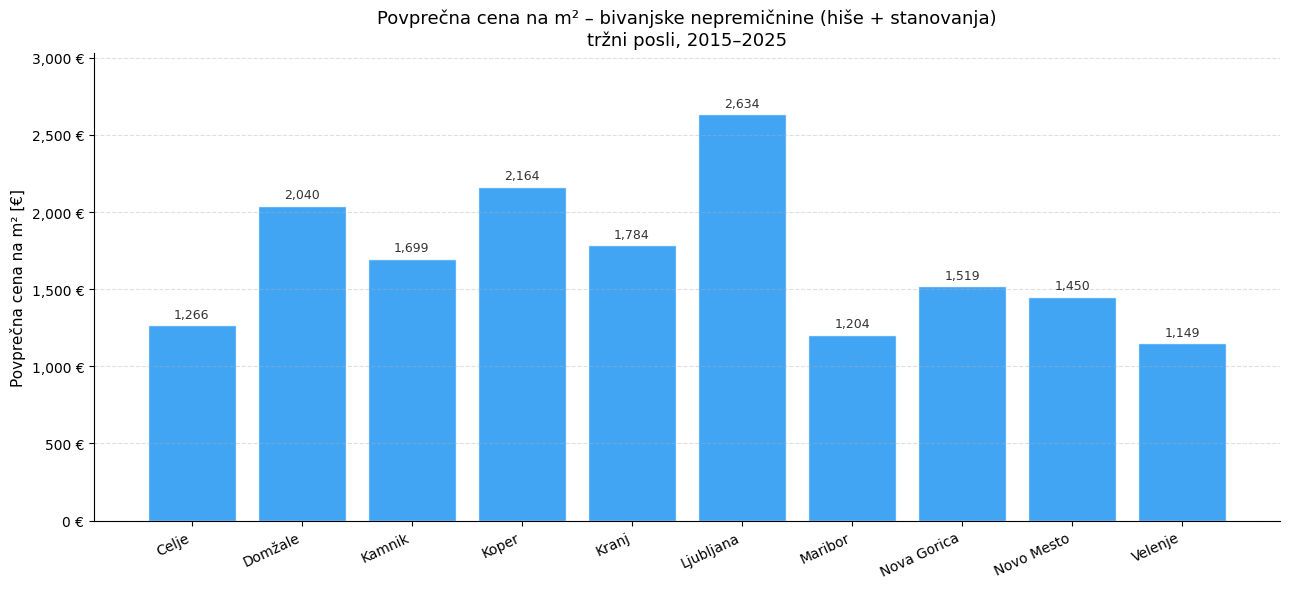


Povzetek – bivanjske nepremičnine (skupaj):
     OBCINA   povprecje     mediana  stevilo
      CELJE 1265.996085 1108.108108     1873
    DOMŽALE 2039.927430 1912.032037     1085
     KAMNIK 1698.661141 1528.594771      766
      KOPER 2163.674521 1955.533597     1190
      KRANJ 1784.225370 1612.903226     1719
  LJUBLJANA 2634.467804 2358.870968    12781
    MARIBOR 1203.874175 1047.847985     6156
NOVA GORICA 1519.068065 1451.976391      622
 NOVO MESTO 1450.404316 1288.135593      887
    VELENJE 1148.607713 1000.000000     1212


: 

: 

: 

In [ ]:
df_biv = df_clean[df_clean["VRSTA_DELA_STAVBE"].isin(BIVANJSKE)].copy()

agg_biv = (
    df_biv
    .groupby("OBCINA")["CENA_M2"]
    .agg(povprecje="mean", mediana="median", stevilo="count")
    .reindex(OBCINE)
    .reset_index()
)

# ── Graf ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    agg_biv["OBCINA"].str.title(),
    agg_biv["povprecje"],
    color="#2196F3", alpha=0.85, edgecolor="white"
)

for bar, val in zip(bars, agg_biv["povprecje"]):
    if pd.notna(val):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 30,
            f"{val:,.0f}",
            ha="center", va="bottom", fontsize=9, color="#333"
        )

ax.set_xticklabels([o.title() for o in OBCINE], rotation=25, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f} €"))
ax.set_ylabel("Povprečna cena na m² [€]", fontsize=11)
ax.set_title("Povprečna cena na m² – bivanjske nepremičnine (hiše + stanovanja)\ntržni posli, 2015–2025", fontsize=13)
ax.set_ylim(0, agg_biv["povprecje"].max() * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\nPovzetek – bivanjske nepremičnine (skupaj):")
print(agg_biv[["OBCINA", "povprecje", "mediana", "stevilo"]].to_string(index=False))

## Ljubljana 2025 – Bivanjske hiše
Podrobna analiza enostanovanjskih hiš (VRSTA_DELA_STAVBE = 1) v Mestni občini Ljubljana za leto 2025.

In [ ]:
# ── Ljubljana 2025: Bivanjske hiše ───────────────────────────────────────────
# VRSTA_DELA_STAVBE = 1 (enostanovanjska hiša), LETO_x = 2025
# Opomba: v 2025 se je kodiranje TRZNOST_POSLA spremenilo (dominantna koda 5.0),
#         zato tržnostni filter ni apliciran.

df_lj25 = df[
    (df['OBCINA'] == 'LJUBLJANA') &
    (df['VRSTA_DELA_STAVBE'] == 1) &
    (df['LETO_x'] == 2025) &
    (df['PRODANA_POVRSINA'] > 0) &
    (df['POGODBENA_CENA_ODSKODNINA'] > 0)
].copy()

df_lj25['CENA_M2'] = df_lj25['POGODBENA_CENA_ODSKODNINA'] / df_lj25['PRODANA_POVRSINA']

q_low25  = df_lj25['CENA_M2'].quantile(0.01)
q_high25 = df_lj25['CENA_M2'].quantile(0.99)
df_lj25c = df_lj25[(df_lj25['CENA_M2'] >= q_low25) & (df_lj25['CENA_M2'] <= q_high25)].copy()

# ── Četrtletna analiza ───────────────────────────────────────────────────────
df_lj25c['DATUM_SKLENITVE_POGODBE'] = pd.to_datetime(
    df_lj25c['DATUM_SKLENITVE_POGODBE'], dayfirst=True, errors='coerce')
df_lj25c['KVARTAL'] = df_lj25c['DATUM_SKLENITVE_POGODBE'].dt.quarter

q_agg = (
    df_lj25c.groupby('KVARTAL')['CENA_M2']
    .agg(povprecje='mean', mediana='median', stevilo='count')
    .reset_index()
)
q_agg['KVARTAL_LABEL'] = q_agg['KVARTAL'].map({1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})

# ── Graf 1: histogram cene/m² ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_lj25c['CENA_M2'], bins=30, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].axvline(df_lj25c['CENA_M2'].mean(),   color='#E53935', lw=2, label=f"Povprečje: {df_lj25c['CENA_M2'].mean():,.0f} €/m²")
axes[0].axvline(df_lj25c['CENA_M2'].median(), color='#1565C0', lw=2, linestyle='--', label=f"Mediana: {df_lj25c['CENA_M2'].median():,.0f} €/m²")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
axes[0].set_xlabel('Cena na m² [€]', fontsize=11)
axes[0].set_ylabel('Število poslov', fontsize=11)
axes[0].set_title('Porazdelitev cene/m²\nLjubljana 2025 – hiše', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].spines[['top','right']].set_visible(False)

# ── Graf 2: povprečna cena/m² po četrtletju ─────────────────────────────────
bars = axes[1].bar(q_agg['KVARTAL_LABEL'], q_agg['povprecje'],
                   color='#2196F3', alpha=0.85, edgecolor='white')
for bar, row in zip(bars, q_agg.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f"{row.povprecje:,.0f}\n(n={row.stevilo})",
                 ha='center', va='bottom', fontsize=8.5, color='#333')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f} €'))
axes[1].set_xlabel('Četrtletje', fontsize=11)
axes[1].set_ylabel('Povprečna cena na m² [€]', fontsize=11)
axes[1].set_title('Povprečna cena/m² po četrtletju\nLjubljana 2025 – hiše', fontsize=12)
axes[1].set_ylim(0, q_agg['povprecje'].max() * 1.2)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# ── Povzetek ─────────────────────────────────────────────────────────────────
print('=== Ljubljana 2025 – Bivanjske hiše (enostanovanjske) ===')
print(f'Skupaj poslov (po čiščenju):  {len(df_lj25c)}')
print()
print('Cena na m²:')
for label, val in [
    ('  Povprečje', df_lj25c['CENA_M2'].mean()),
    ('  Mediana  ', df_lj25c['CENA_M2'].median()),
    ('  Std. dev.', df_lj25c['CENA_M2'].std()),
]:
    print(f'{label}:  {val:>8,.0f} €/m²')
print()
print('Percentili cene/m²:')
for p in [10, 25, 50, 75, 90]:
    print(f'  {p:2d}. percentil: {df_lj25c["CENA_M2"].quantile(p/100):>8,.0f} €/m²')
print()
print('Skupna cena:')
print(f'  Povprečje:   {df_lj25c["POGODBENA_CENA_ODSKODNINA"].mean():>12,.0f} €')
print(f'  Mediana:     {df_lj25c["POGODBENA_CENA_ODSKODNINA"].median():>12,.0f} €')
print()
print('Prodana površina:')
print(f'  Povprečje:   {df_lj25c["PRODANA_POVRSINA"].mean():>8,.1f} m²')
print(f'  Mediana:     {df_lj25c["PRODANA_POVRSINA"].median():>8,.1f} m²')
print()
print('Trend po četrtletjih:')
for _, row in q_agg.iterrows():
    print(f'  {row["KVARTAL_LABEL"]}: povprečje {row["povprecje"]:>8,.0f} €/m²  |  mediana {row["mediana"]:>8,.0f} €/m²  |  n={int(row["stevilo"])}')


NameError: name 'df' is not defined

: 

: 

: 